In [ ]:
import pandas as pd
import numpy as np

final_df = pd.read_csv("final_provider_dataset.csv")
X = final_df.drop(["Provider", "Fraud"], axis=1)
y = final_df["Fraud"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))
class_weights

{np.int64(0): np.float64(0.5515225666122893),
 np.int64(1): np.float64(5.352242744063324)}

In [ ]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(class_weight="balanced", max_iter=500)
logreg.fit(X_train, y_train)

y_pred_log = logreg.predict(X_test)
y_prob_log = logreg.predict_proba(X_test)[:, 1]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)

def evaluate_model(name, y_test, y_pred, y_prob):
    print(f"\nModel: {name}")
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("PR-AUC:", average_precision_score(y_test, y_prob))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

In [ ]:
evaluate_model("Logistic Regression", y_test, y_pred_log, y_prob_log)
evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf)
evaluate_model("Gradient Boosting", y_test, y_pred_gb, y_prob_gb)


Model: Logistic Regression
Precision: 0.39855072463768115
Recall: 0.8661417322834646
F1: 0.5459057071960298
ROC-AUC: 0.9453700016698565
PR-AUC: 0.7129235140106894
Confusion Matrix:
 [[1060  166]
 [  17  110]]

Model: Random Forest
Precision: 0.7142857142857143
Recall: 0.5118110236220472
F1: 0.5963302752293578
ROC-AUC: 0.9468343373880875
PR-AUC: 0.7195700392488176
Confusion Matrix:
 [[1200   26]
 [  62   65]]

Model: Gradient Boosting
Precision: 0.7888888888888889
Recall: 0.5590551181102362
F1: 0.6543778801843319
ROC-AUC: 0.9519755687145959
PR-AUC: 0.7418806241862924
Confusion Matrix:
 [[1207   19]
 [  56   71]]


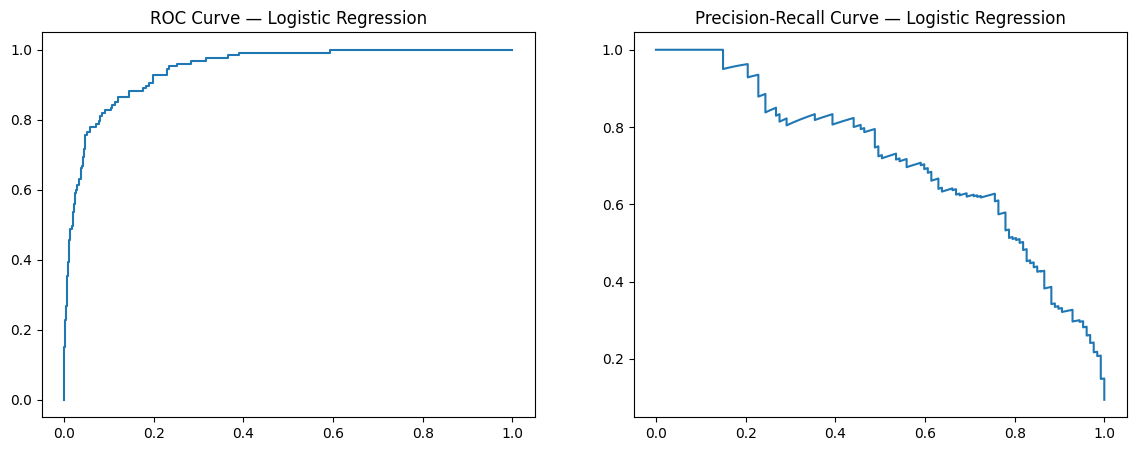

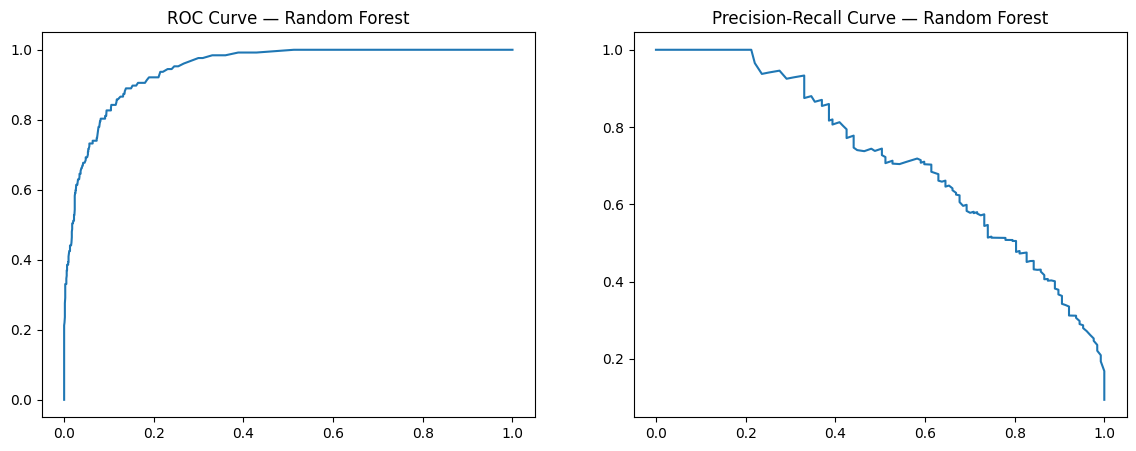

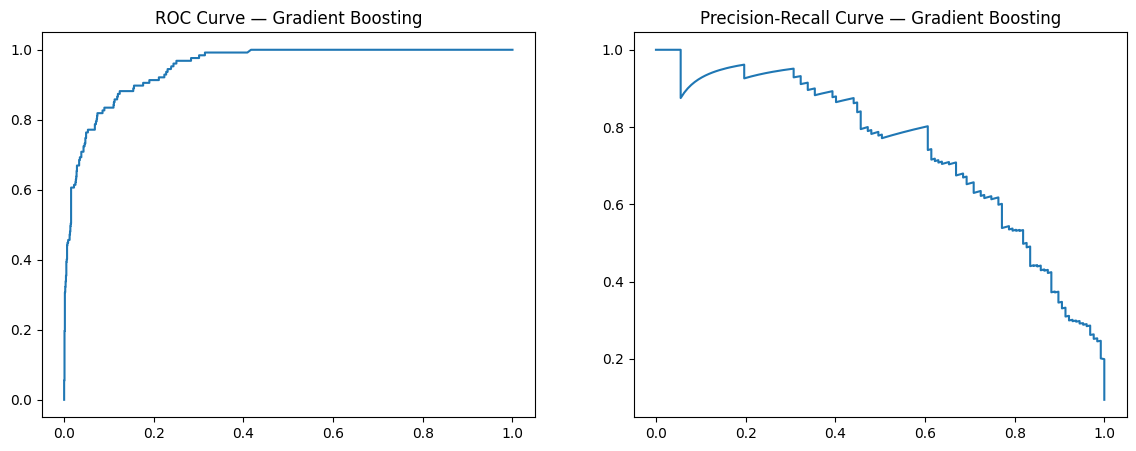

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

def plot_curves(y_test, y_prob, title):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    plt.figure(figsize=(14, 5))

    plt.subplot(1,2,1)
    plt.plot(fpr, tpr)
    plt.title(f"ROC Curve — {title}")

    plt.subplot(1,2,2)
    plt.plot(recall, precision)
    plt.title(f"Precision-Recall Curve — {title}")

    plt.show()

plot_curves(y_test, y_prob_log, "Logistic Regression")
plot_curves(y_test, y_prob_rf, "Random Forest")
plot_curves(y_test, y_prob_gb, "Gradient Boosting")

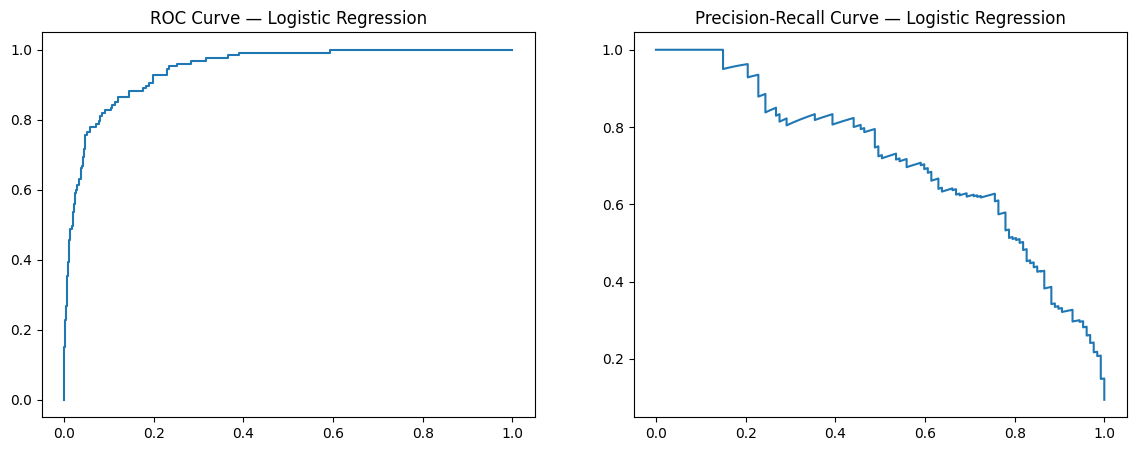

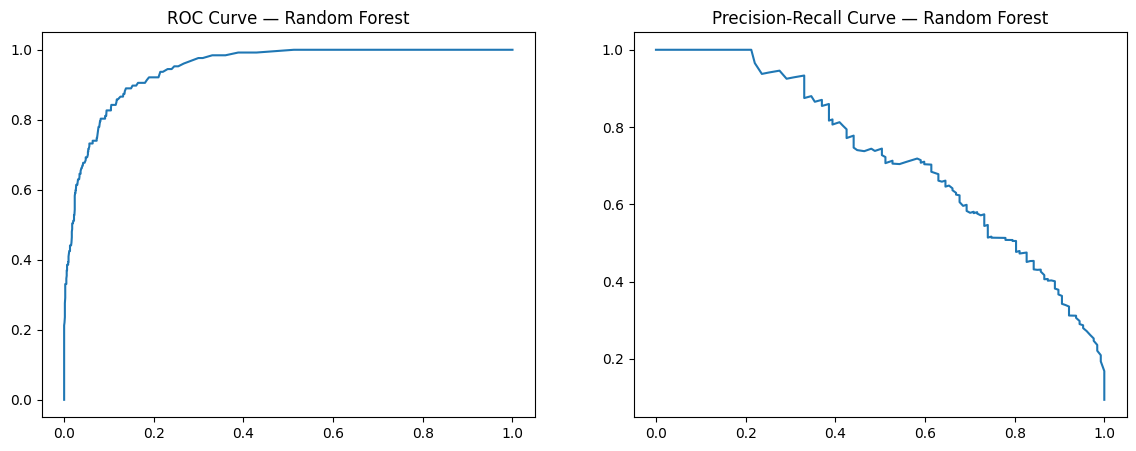

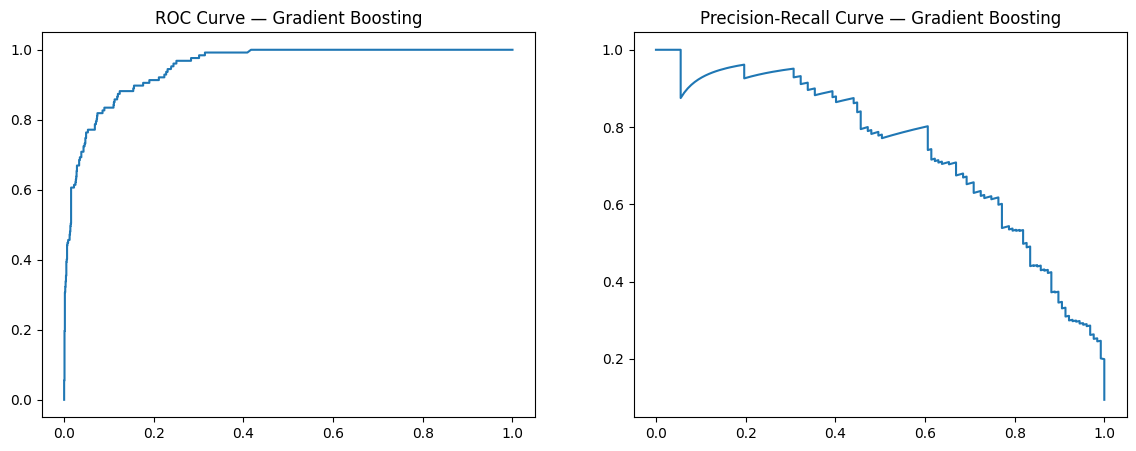

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

def plot_curves(y_test, y_prob, title):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    plt.figure(figsize=(14, 5))

    plt.subplot(1,2,1)
    plt.plot(fpr, tpr)
    plt.title(f"ROC Curve — {title}")

    plt.subplot(1,2,2)
    plt.plot(recall, precision)
    plt.title(f"Precision-Recall Curve — {title}")

    plt.show()

plot_curves(y_test, y_prob_log, "Logistic Regression")
plot_curves(y_test, y_prob_rf, "Random Forest")
plot_curves(y_test, y_prob_gb, "Gradient Boosting")

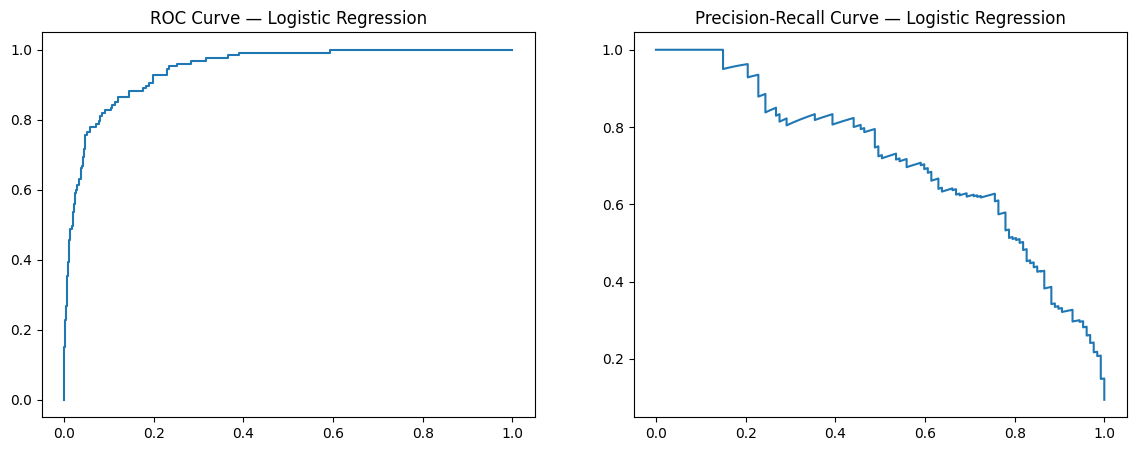

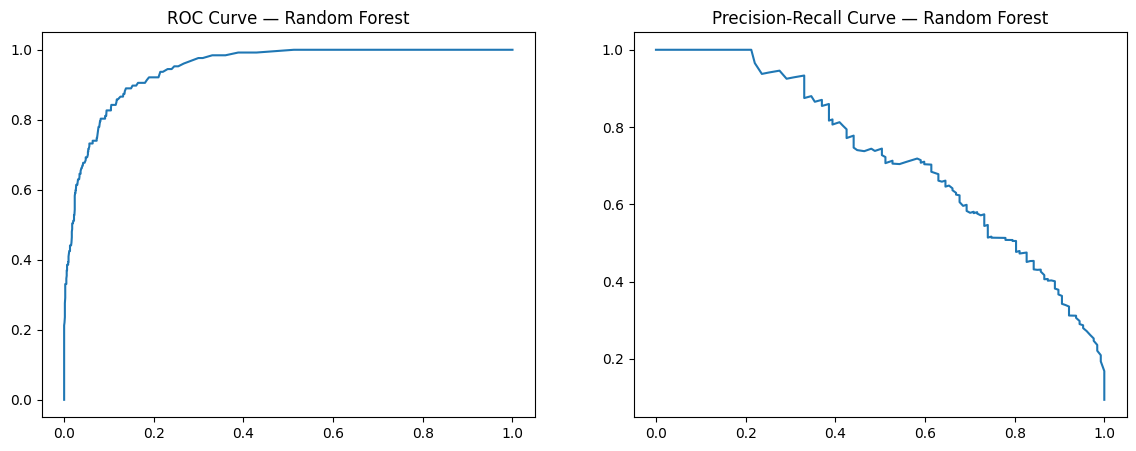

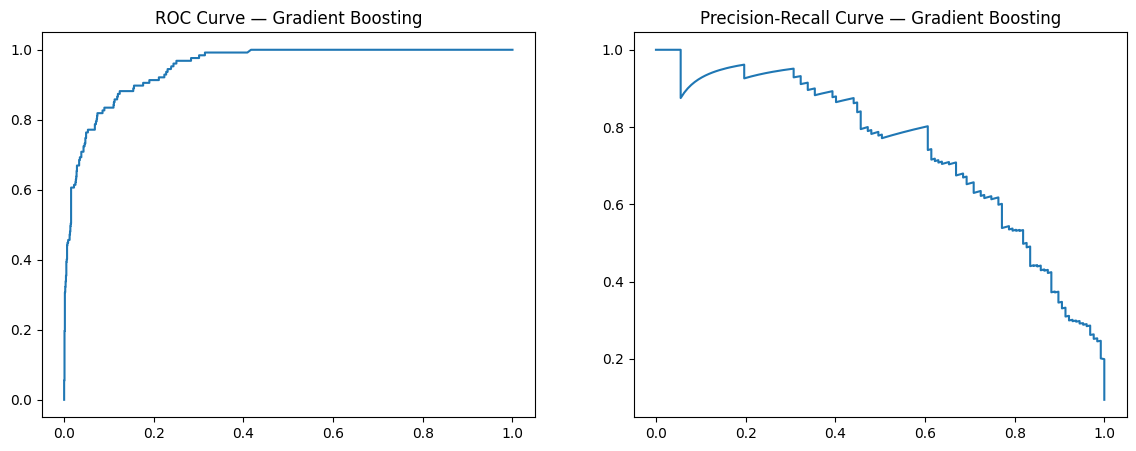

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

def plot_curves(y_test, y_prob, title):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    plt.figure(figsize=(14, 5))

    plt.subplot(1,2,1)
    plt.plot(fpr, tpr)
    plt.title(f"ROC Curve — {title}")

    plt.subplot(1,2,2)
    plt.plot(recall, precision)
    plt.title(f"Precision-Recall Curve — {title}")

    plt.show()

plot_curves(y_test, y_prob_log, "Logistic Regression")
plot_curves(y_test, y_prob_rf, "Random Forest")
plot_curves(y_test, y_prob_gb, "Gradient Boosting")

In [ ]:
importances = rf.feature_importances_
rf_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

rf_importance_df.head(15)

,feature,importance
1,inpatient_total_reimbursement,0.149962
14,n_unique_proc_codes,0.106580
0,inpatient_claim_count,0.092442
3,inpatient_unique_beneficiaries,0.087695
2,inpatient_avg_reimbursement,0.076279
13,n_unique_diag_codes,0.061721
15,total_claim_count,0.056486
17,avg_reimbursement_overall,0.049670
5,outpatient_total_reimbursement,0.047555
4,outpatient_claim_count,0.044427


In [ ]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coef": logreg.coef_[0]
}).sort_values("coef", ascending=False)

coef_df.head(15)

,feature,coef
13,n_unique_diag_codes,0.004436
15,total_claim_count,0.002533
4,outpatient_claim_count,0.002302
14,n_unique_proc_codes,0.000788
6,outpatient_avg_reimbursement,0.000244
0,inpatient_claim_count,0.000231
2,inpatient_avg_reimbursement,0.000116
16,ip_claim_ratio,0.000074
17,avg_reimbursement_overall,0.000037
1,inpatient_total_reimbursement,0.000007
